## Business analyst Work- Customer Segmentation to help Business to find their valuable customers

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
upload = files.upload()

Saving Train.csv to Train.csv


In [4]:
df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [6]:
df.shape

(8068, 11)

In [8]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [7]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [19]:
# Define columns for imputation
numerical_cols = ['Work_Experience', 'Family_Size', 'Age']
categorical_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


In [20]:
numerical_imputer = SimpleImputer(strategy='mean')  # Impute numerical with mean
categorical_imputer = SimpleImputer(strategy='most_frequent')

In [21]:
# Apply imputation
df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

In [22]:
print("\nMissing Values after imputation:")
print(df.isnull().sum())


Missing Values after imputation:
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
Cluster            0
dtype: int64


In [40]:
# Feature Selection & Preprocessing
# Focus on purchasing behavior & demographics
clustering_features = ['Gender', 'Age', 'Ever_Married', 'Graduated', 'Profession',
                       'Work_Experience', 'Spending_Score', 'Family_Size']
X = df[clustering_features].copy()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Work_Experience', 'Family_Size']),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score'])
    ])

X_processed = preprocessor.fit_transform(X)

In [41]:
# Determine Optimal K
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    silhouette_avg = silhouette_score(X_processed, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)


In [39]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_processed)

In [42]:
# Cluster Sizes
print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())


Cluster Sizes:
Cluster
0    1506
1    3090
2    1695
3    1777
Name: count, dtype: int64


In [43]:
# Cluster Profiles (Means)
cluster_profiles = df.groupby('Cluster').mean(numeric_only=True)
print("\nCluster Profiles (Means):")
print(cluster_profiles)


Cluster Profiles (Means):
           Gender  Ever_Married        Age  Graduated  Profession  \
Cluster                                                             
0        0.475432      0.537185  37.782205   0.693891    2.518592   
1        0.637217      0.987379  58.115858   0.735275    2.619417   
2        0.573451      0.163422  27.195280   0.211799    3.946313   
3        0.427687      0.363534  38.332583   0.770962    2.018008   

         Work_Experience  Spending_Score  Family_Size     Var_1  
Cluster                                                          
0               8.475432        1.416999     2.484728  4.252988  
1               0.987055        0.785437     2.785761  4.336246  
2               1.370501        1.848968     4.476696  3.731563  
3               1.021384        1.844119     1.748452  4.126055  


In [47]:
# Cluster Profiles (Counts for Categorical)
for cat_col in categorical_cols[:-1]:  # Exclude 'Var_1' and 'Segmentation'
    print(f"\nCluster Profiles - {cat_col} Counts:")
    print(df.groupby('Cluster')[cat_col].value_counts())


Cluster Profiles - Gender Counts:
Cluster  Gender
0        0          790
         1          716
1        1         1969
         0         1121
2        1          972
         0          723
3        0         1017
         1          760
Name: count, dtype: int64

Cluster Profiles - Ever_Married Counts:
Cluster  Ever_Married
0        1                809
         0                697
1        1               3051
         0                 39
2        0               1418
         1                277
3        0               1131
         1                646
Name: count, dtype: int64

Cluster Profiles - Graduated Counts:
Cluster  Graduated
0        1            1045
         0             461
1        1            2272
         0             818
2        0            1336
         1             359
3        1            1370
         0             407
Name: count, dtype: int64

Cluster Profiles - Profession Counts:
Cluster  Profession
0        0              530
         5      

# Visualizations

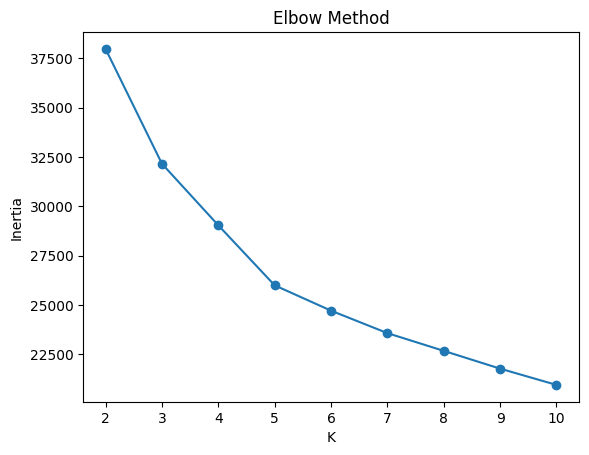

In [48]:
#Elbow Method
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


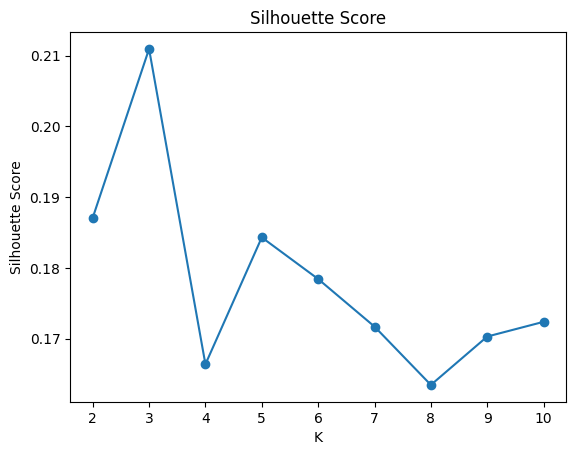

In [49]:
# Silhouette Score
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()


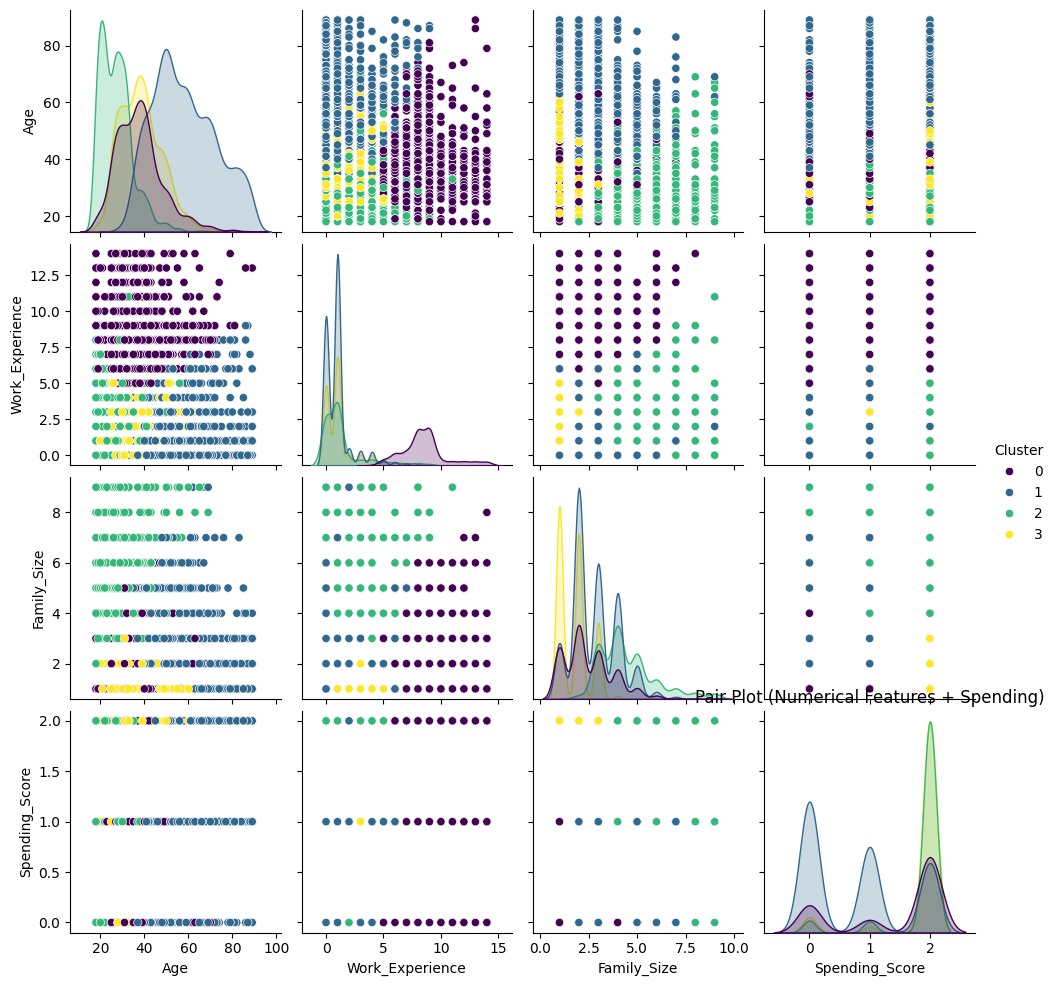

In [50]:
# Pair Plot (Numerical)
num_cols = ['Age', 'Work_Experience', 'Family_Size']
if len(num_cols) >= 2:
    sns.pairplot(df, vars=num_cols + ['Spending_Score'], hue='Cluster', palette='viridis')
    plt.title('Pair Plot (Numerical Features + Spending)')
    plt.show()

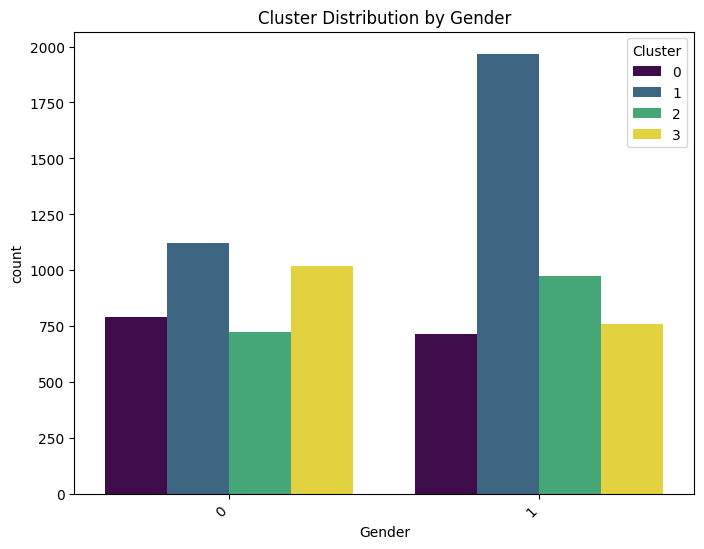

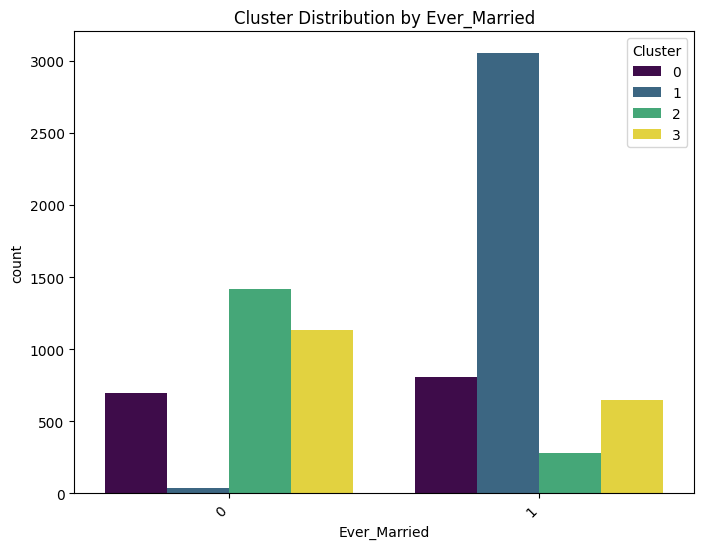

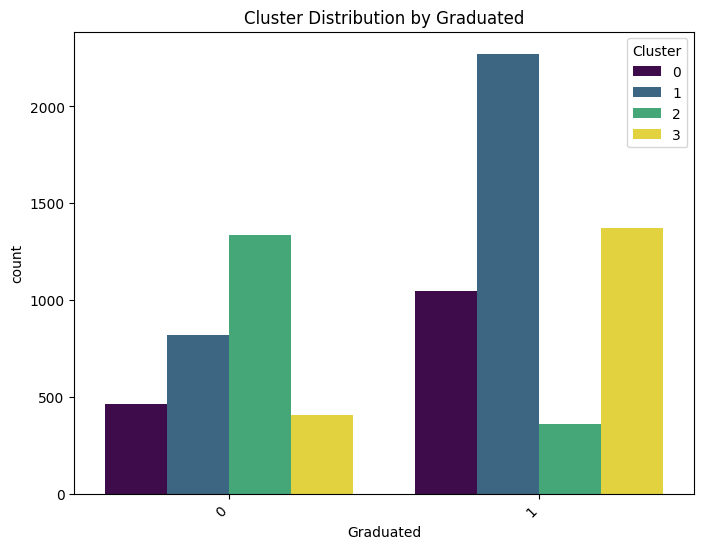

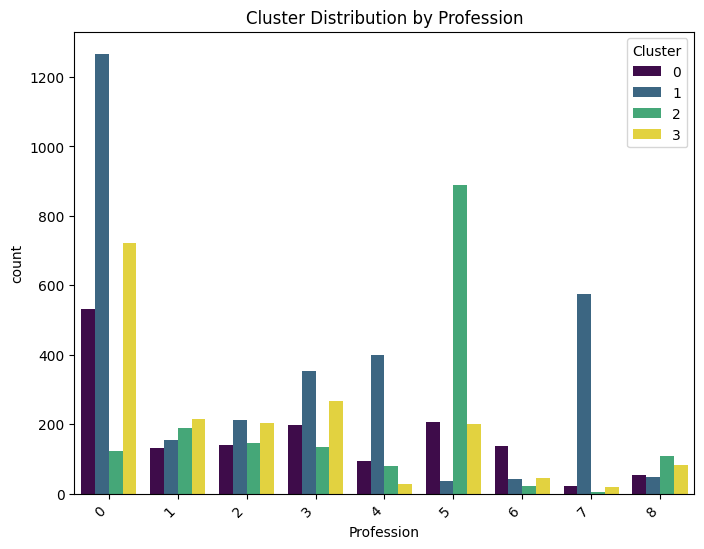

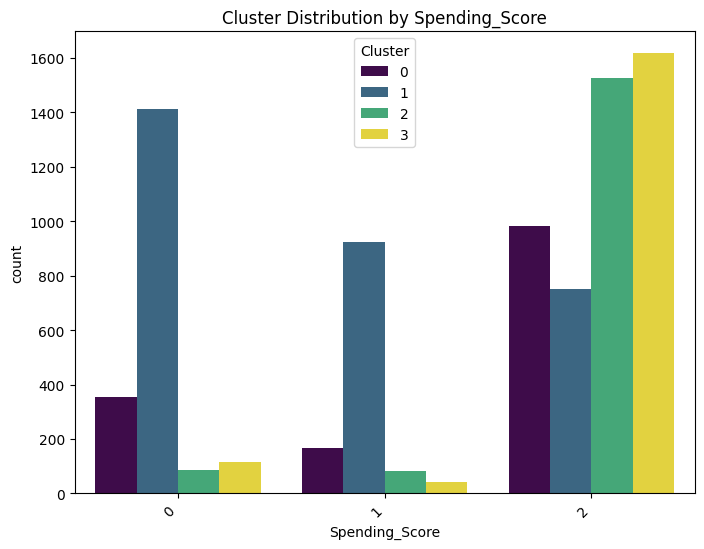

In [51]:
# Count Plots (Categorical)
for cat_col in categorical_cols[:-1]:  # Exclude 'Var_1' and 'Segmentation'
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=cat_col, hue='Cluster', palette='viridis')
    plt.title(f'Cluster Distribution by {cat_col}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

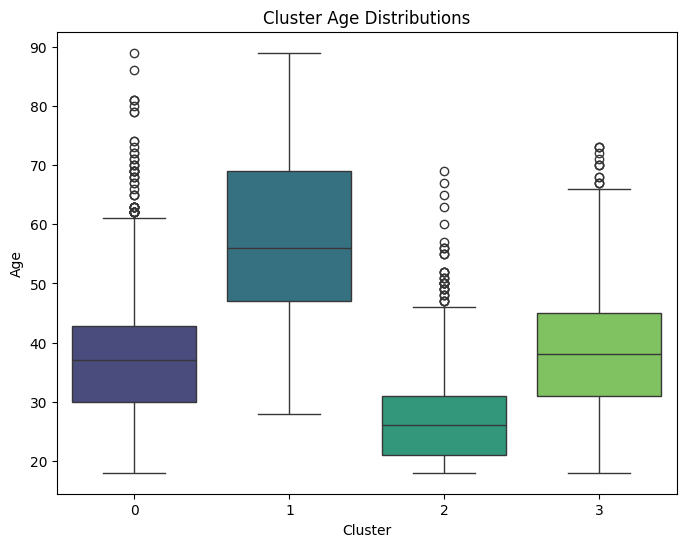

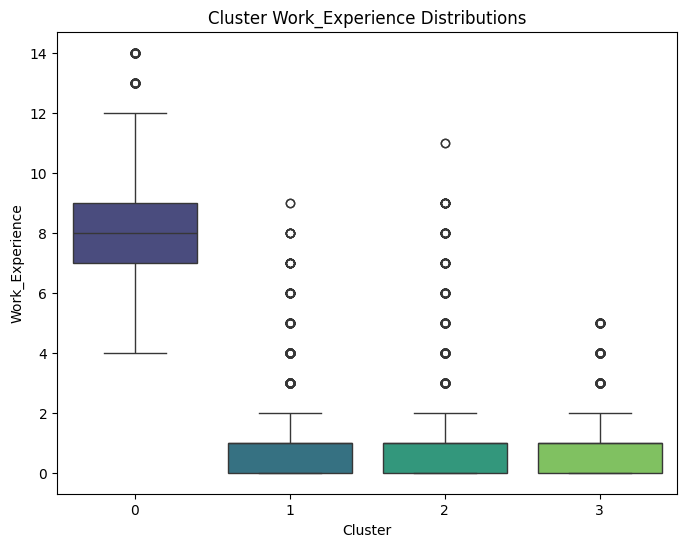

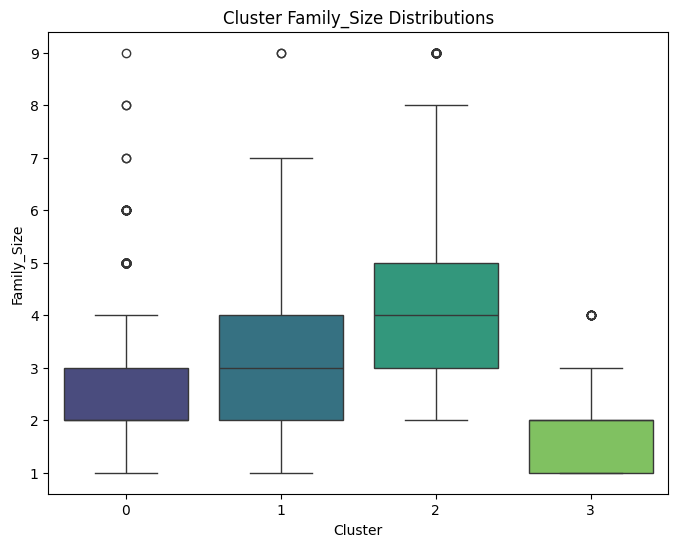

In [52]:
# Box Plots (Numerical vs. Cluster)
for num_col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Cluster', y=num_col, palette='viridis')
    plt.title(f'Cluster {num_col} Distributions')
    plt.show()


Cluster Profiles (Means):
           Gender  Ever_Married        Age  Graduated  Profession  \
Cluster                                                             
0        0.475432      0.537185  37.782205   0.693891    2.518592   
1        0.637217      0.987379  58.115858   0.735275    2.619417   
2        0.573451      0.163422  27.195280   0.211799    3.946313   
3        0.427687      0.363534  38.332583   0.770962    2.018008   

         Work_Experience  Spending_Score  Family_Size     Var_1  
Cluster                                                          
0               8.475432        1.416999     2.484728  4.252988  
1               0.987055        0.785437     2.785761  4.336246  
2               1.370501        1.848968     4.476696  3.731563  
3               1.021384        1.844119     1.748452  4.126055  


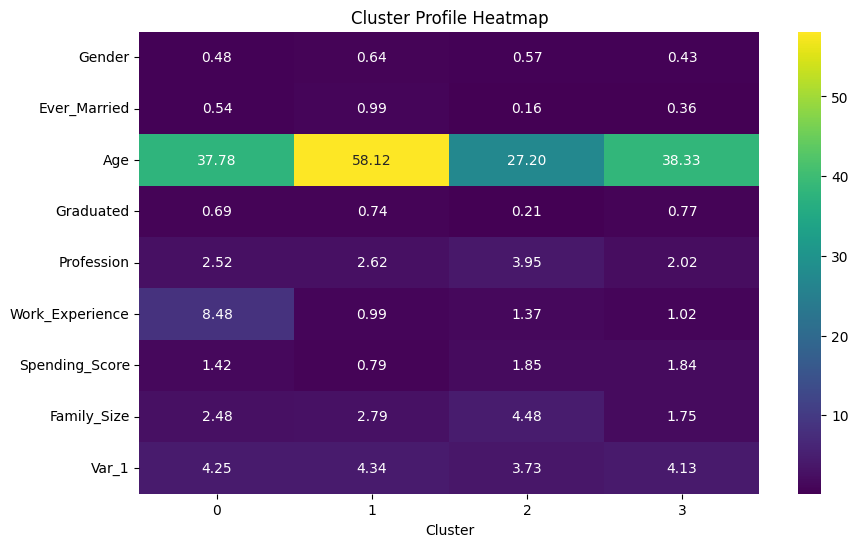

In [55]:

cluster_profiles = df.groupby('Cluster').mean(numeric_only=True)
print("\nCluster Profiles (Means):")
print(cluster_profiles)

# Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles.T, cmap='viridis', annot=True, fmt=".2f")
plt.title("Cluster Profile Heatmap")
plt.show()


In [54]:
def interpret_clusters(df, cluster_profiles, optimal_k):

    print("\n--- Business Interpretation ---\n")

    print("Based on the cluster profiles and visualizations, we can interpret the customer segments:")

    for cluster_num in range(optimal_k):
        print(f"\nCluster {cluster_num}:")
        cluster_data = df[df['Cluster'] == cluster_num]
        print(f"- Size: {len(cluster_data)} customers")
        for feature, mean_val in cluster_profiles.loc[cluster_num].items():
            print(f"- Average {feature}: {mean_val:.2f}")




# Call the interpretation function
interpret_clusters(df.copy(), cluster_profiles.copy(), optimal_k)


--- Business Interpretation ---

Based on the cluster profiles and visualizations, we can interpret the customer segments:

Cluster 0:
- Size: 1506 customers
- Average Gender: 0.48
- Average Ever_Married: 0.54
- Average Age: 37.78
- Average Graduated: 0.69
- Average Profession: 2.52
- Average Work_Experience: 8.48
- Average Spending_Score: 1.42
- Average Family_Size: 2.48
- Average Var_1: 4.25

Cluster 1:
- Size: 3090 customers
- Average Gender: 0.64
- Average Ever_Married: 0.99
- Average Age: 58.12
- Average Graduated: 0.74
- Average Profession: 2.62
- Average Work_Experience: 0.99
- Average Spending_Score: 0.79
- Average Family_Size: 2.79
- Average Var_1: 4.34

Cluster 2:
- Size: 1695 customers
- Average Gender: 0.57
- Average Ever_Married: 0.16
- Average Age: 27.20
- Average Graduated: 0.21
- Average Profession: 3.95
- Average Work_Experience: 1.37
- Average Spending_Score: 1.85
- Average Family_Size: 4.48
- Average Var_1: 3.73

Cluster 3:
- Size: 1777 customers
- Average Gender: 0